In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np

In [2]:
df=pd.read_csv("../data/raw/tesla_stocks.csv")

In [3]:
df.head()


,Date,Close/Last,Volume,Open,High,Low
0,12/06/2024,$389.22,81455830,$377.42,$389.49,$370.80
1,12/05/2024,$369.49,81403570,$359.87,$375.43,$359.50
2,12/04/2024,$357.93,50810870,$353.00,$358.10,$348.60
3,12/03/2024,$351.42,58267200,$351.80,$355.69,$348.20
4,12/02/2024,$357.09,77986480,$352.38,$360.00,$351.1501


In [4]:
df.tail()

,Date,Close/Last,Volume,Open,High,Low
2512,12/12/2014,$13.80,107507556,$13.6547,$14.112,$13.6333
2513,12/11/2014,$13.9253,100266835,$14.0353,$14.362,$13.882
2514,12/10/2014,$13.9893,109622540,$14.2753,$14.4513,$13.8467
2515,12/09/2014,$14.4593,141405904,$13.956,$14.5153,$13.618
2516,12/08/2014,$14.2907,138260571,$14.7693,$14.9907,$14.156


In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')
df.reset_index(inplace=True, drop=True)
df.head()

,Date,Close/Last,Volume,Open,High,Low
0,2014-12-08,$14.2907,138260571,$14.7693,$14.9907,$14.156
1,2014-12-09,$14.4593,141405904,$13.956,$14.5153,$13.618
2,2014-12-10,$13.9893,109622540,$14.2753,$14.4513,$13.8467
3,2014-12-11,$13.9253,100266835,$14.0353,$14.362,$13.882
4,2014-12-12,$13.80,107507556,$13.6547,$14.112,$13.6333


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        2517 non-null   datetime64[us]
 1   Close/Last  2517 non-null   str           
 2   Volume      2517 non-null   int64         
 3   Open        2517 non-null   str           
 4   High        2517 non-null   str           
 5   Low         2517 non-null   str           
dtypes: datetime64[us](1), int64(1), str(4)
memory usage: 118.1 KB


In [7]:
df.isnull().sum()

Date          0
Close/Last    0
Volume        0
Open          0
High          0
Low           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['Open'] = df['Open'].str.replace('$', '', regex=False).astype(float)
df['High'] = df['High'].str.replace('$', '', regex=False).astype(float)
df['Low'] = df['Low'].str.replace('$', '', regex=False).astype(float)
df['Close'] = df['Close/Last'].str.replace('$', '', regex=False).astype(float)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        2517 non-null   datetime64[us]
 1   Close/Last  2517 non-null   str           
 2   Volume      2517 non-null   int64         
 3   Open        2517 non-null   float64       
 4   High        2517 non-null   float64       
 5   Low         2517 non-null   float64       
 6   Close       2517 non-null   float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 137.8 KB


In [11]:
df.drop(columns=['Close/Last'], inplace=True)   

In [12]:
df.describe()

,Date,Volume,Open,High,Low,Close
count,2517,2.517000e+03,2517.000000,2517.000000,2517.000000,2517.000000
mean,2019-12-07 20:10:00.715137,1.121374e+08,112.999237,115.523752,110.372709,112.985214
min,2014-12-08 00:00:00,1.065415e+07,9.488000,10.331300,9.403300,9.578000
25%,2017-06-08 00:00:00,6.657777e+07,17.026000,17.300000,16.719300,17.016700
50%,2019-12-06 00:00:00,9.283534e+07,25.111300,25.574000,24.673300,25.176000
75%,2022-06-07 00:00:00,1.294696e+08,219.400000,222.990000,213.740000,218.890000
max,2024-12-06 00:00:00,9.140809e+08,411.470000,414.496600,405.666600,409.970000
std,NaN,7.410916e+07,111.712843,114.261293,109.016181,111.647804


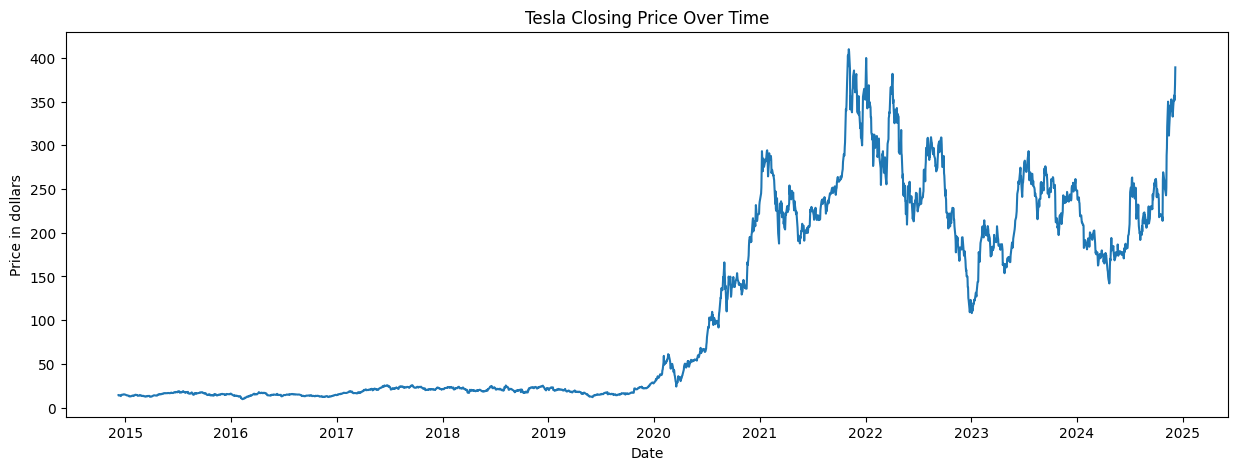

In [13]:
plt.figure(figsize=(15,5))

plt.plot(df['Date'], df['Close'])

plt.xlabel('Date')
plt.ylabel('Price in dollars')
plt.title('Tesla Closing Price Over Time')

plt.show()

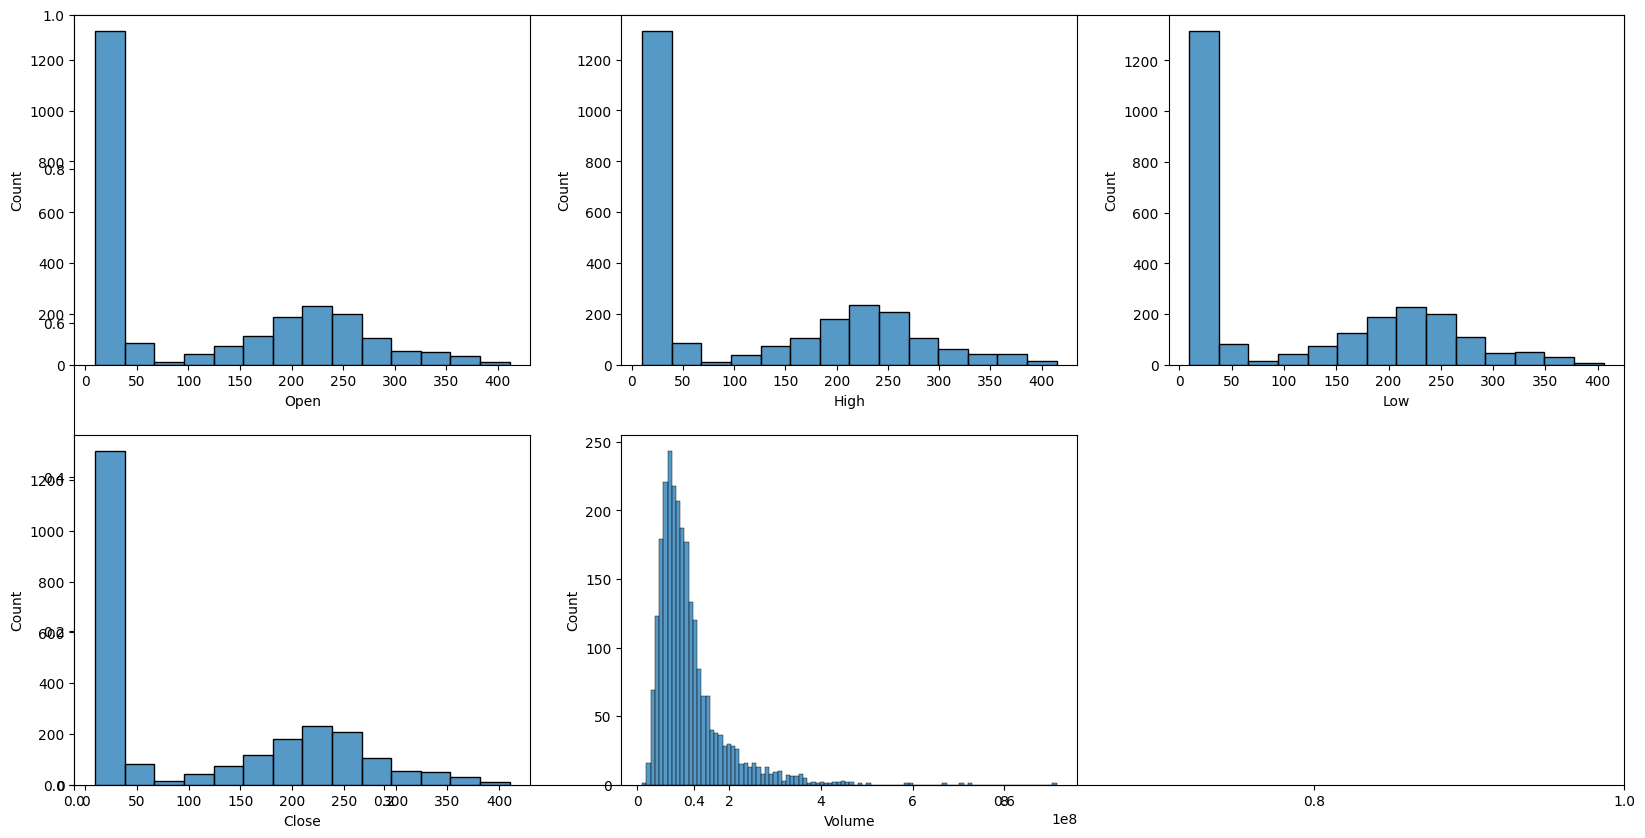

In [14]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']

plt.subplots(figsize=(20,10))

for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sb.histplot(df[col])
plt.show()

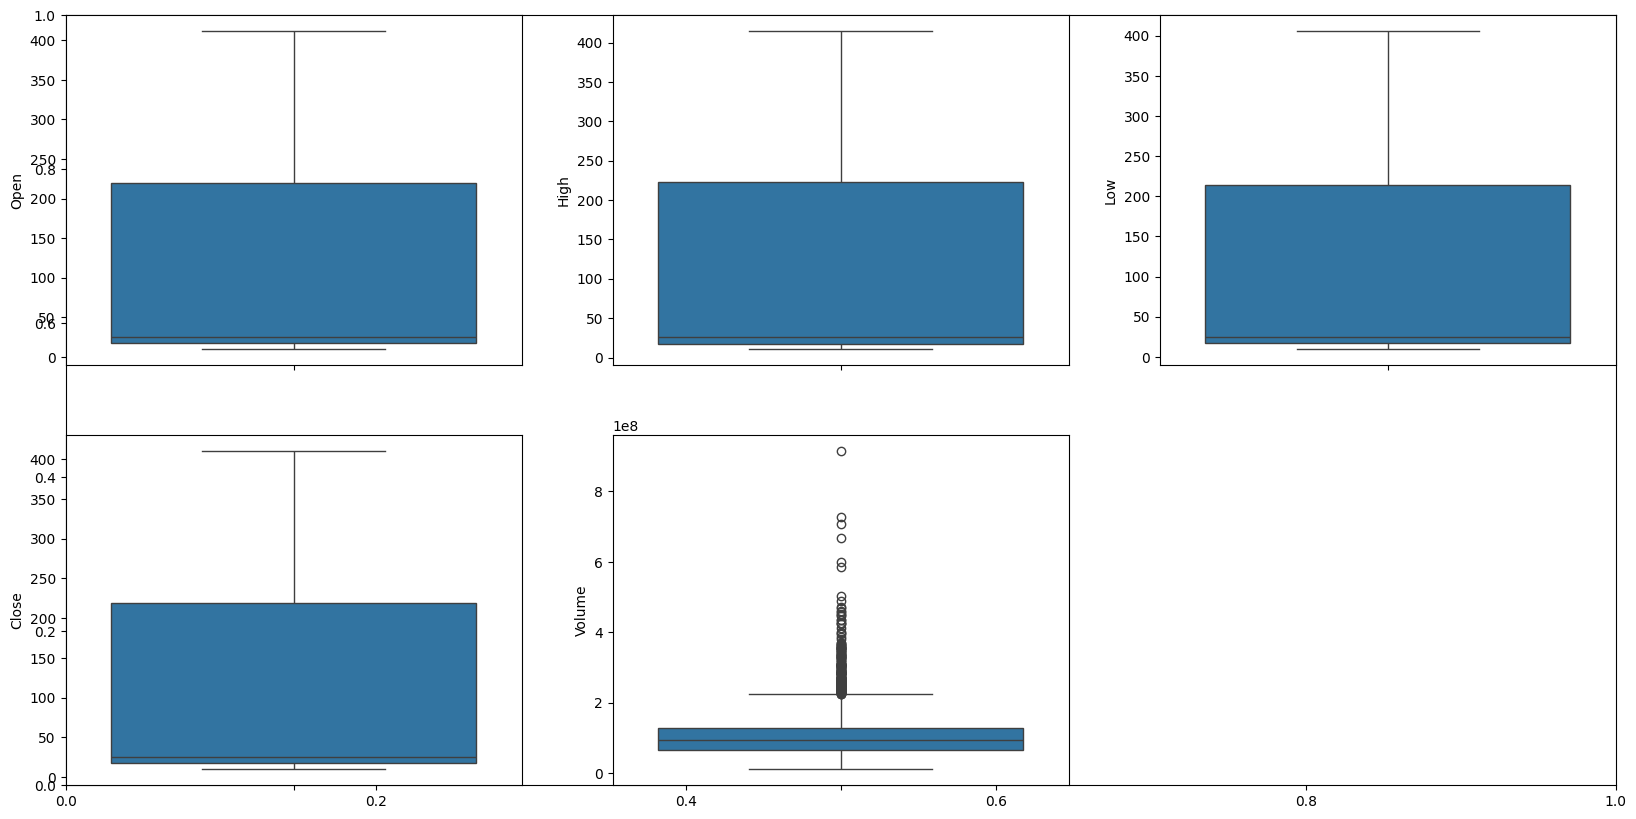

In [15]:
plt.subplots(figsize=(20,10))
for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sb.boxplot(df[col])
plt.show()

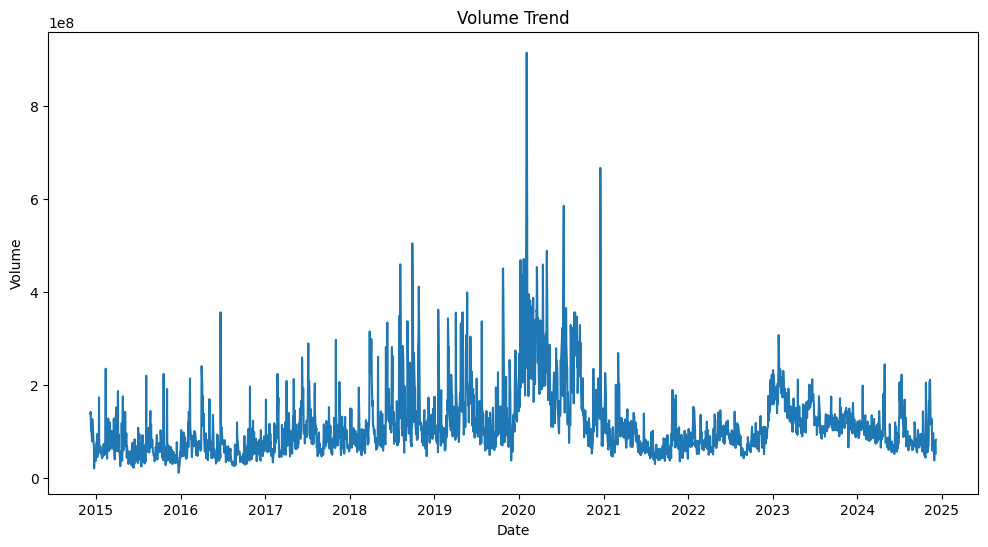

In [16]:
#volume visualization
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Volume'])
plt.xlabel('Date')
plt.ylabel('Volume')
plt.title('Volume Trend')
plt.show()

In [17]:
df.to_csv(
    "../data/processed/tesla_stocks_cleaned.csv",
    index=False
)